# 3D Cylinder Grid Visualization with Matplotlib

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

## Basic Cylinder Grid

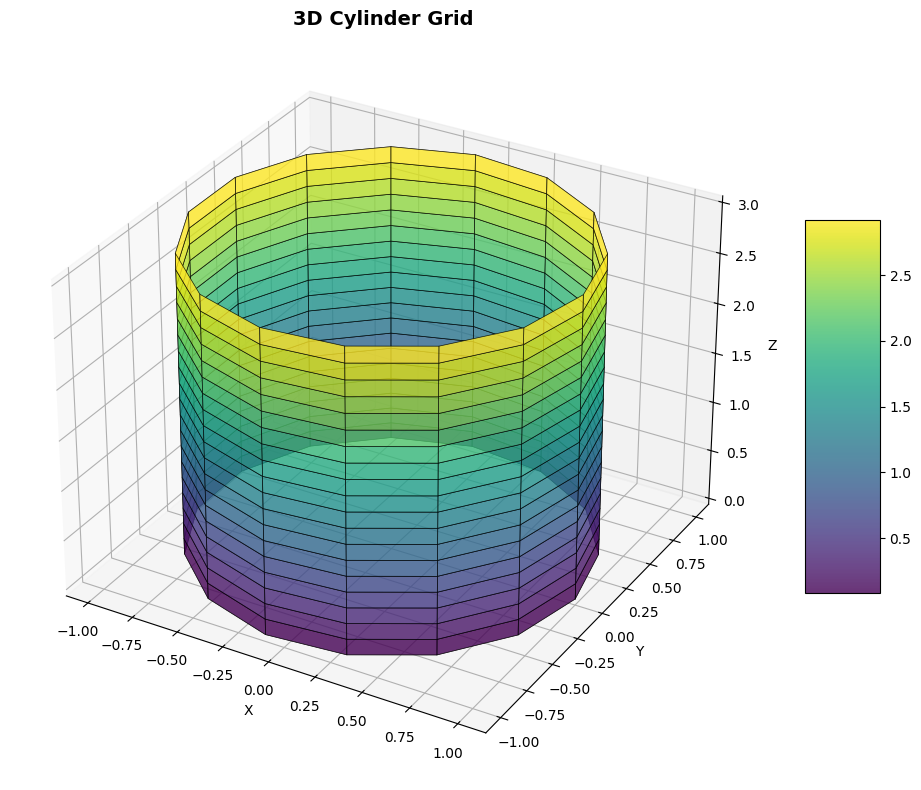

In [5]:
# Create cylinder grid using polar coordinates
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Parameters
radius = 1.0
height = 3.0
num_theta = 16  # Points around circumference
num_z = 20      # Points along height

# Create meshgrid
theta = np.linspace(0, 2*np.pi, num_theta)
z = np.linspace(0, height, num_z)
Theta, Z = np.meshgrid(theta, z)

# Convert to Cartesian coordinates
X = radius * np.cos(Theta)
Y = radius * np.sin(Theta)

# Plot surface
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='black', linewidth=0.5)

# Add vertical lines for the grid
for t in theta:
    x_line = radius * np.cos(t)
    y_line = radius * np.sin(t)
    z_line = np.linspace(0, height, num_z)
    ax.plot([x_line]*len(z_line), [y_line]*len(z_line), z_line, 'k-', linewidth=0.5, alpha=0.6)

# Add horizontal lines for the grid
for z_val in z:
    x_circle = radius * np.cos(theta)
    y_circle = radius * np.sin(theta)
    z_circle = np.ones_like(theta) * z_val
    ax.plot(x_circle, y_circle, z_circle, 'k-', linewidth=0.5, alpha=0.6)

# Labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Cylinder Grid', fontsize=14, fontweight='bold')

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

## Rotatable Cylinder Grid with Custom Colors

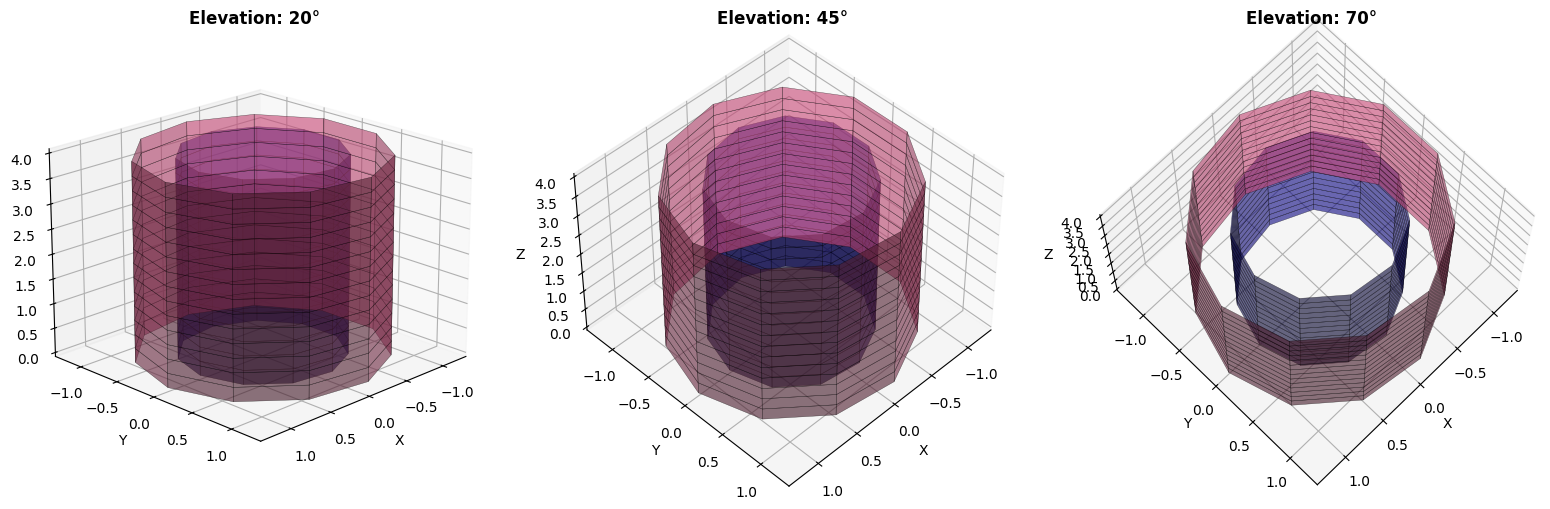

In [6]:
# Create multiple cylinders with different viewing angles
fig = plt.figure(figsize=(16, 5))

# Parameters
radii = [0.8, 1.2]
height = 4.0
num_theta = 12
num_z = 15
angles = [20, 45, 70]  # Elevation angles

for idx, angle in enumerate(angles):
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    
    # Create meshgrid
    theta = np.linspace(0, 2*np.pi, num_theta)
    z = np.linspace(0, height, num_z)
    Theta, Z = np.meshgrid(theta, z)
    
    # Plot multiple cylinders with different radii
    for i, radius in enumerate(radii):
        X = radius * np.cos(Theta)
        Y = radius * np.sin(Theta)
        
        # Color based on radius
        color = cm.plasma(i / len(radii))
        ax.plot_surface(X, Y, Z, alpha=0.6, color=color, edgecolor='black', linewidth=0.3)
    
    # Set viewing angle
    ax.view_init(elev=angle, azim=45)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Elevation: {angle}°', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Wire Frame Cylinder Grid (for Electrode Probe Visualization)

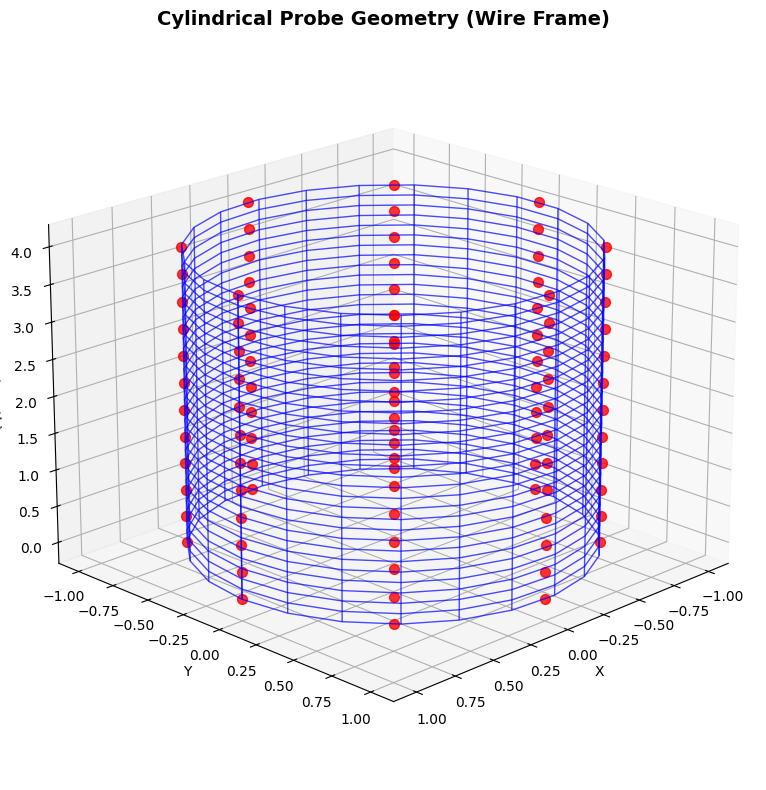

Total electrode points: 96


In [4]:
# Create wireframe cylinder - useful for probe geometry visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Parameters
radius = 1.0
height = 4.0
num_theta = 24
num_z = 30

# Create meshgrid
theta = np.linspace(0, 2*np.pi, num_theta)
z = np.linspace(0, height, num_z)
Theta, Z = np.meshgrid(theta, z)

# Convert to Cartesian coordinates
X = radius * np.cos(Theta)
Y = radius * np.sin(Theta)

# Plot wireframe
ax.plot_wireframe(X, Y, Z, color='blue', linewidth=1, alpha=0.7)

# Add scatter points at grid intersections to simulate electrode locations
num_points_theta = 8
num_points_z = 12
theta_points = np.linspace(0, 2*np.pi, num_points_theta, endpoint=False)
z_points = np.linspace(0, height, num_points_z)

for t in theta_points:
    for z_val in z_points:
        x = radius * np.cos(t)
        y = radius * np.sin(t)
        ax.scatter(x, y, z_val, c='red', s=50, marker='o', alpha=0.8)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z (Depth)')
ax.set_title('Cylindrical Probe Geometry (Wire Frame)', fontsize=14, fontweight='bold')

# Set viewing angle
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

print(f"Total electrode points: {num_points_theta * num_points_z}")

## Custom Cylinder: 14mm Diameter with Perforated Base (1mm holes, 3.5mm height)

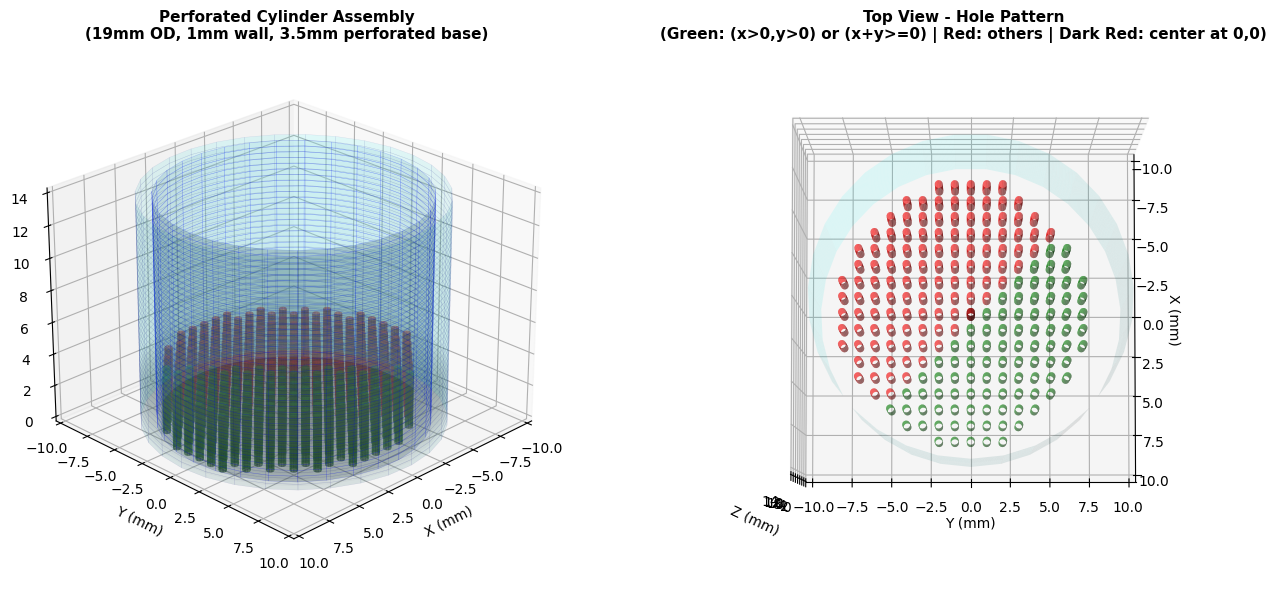

Cylinder Specifications:
  Outer Diameter: 19.0 mm
  Wall Thickness: 1.0 mm
  Inner Diameter: 17.0 mm
  Perforated Base Height: 3.5 mm
  Total Height: 14.0 mm
  Hole Spacing: 1.0 mm
  Hole Diameter: 0.5 mm
  Hole Pattern per Row: [5, 9, 11, 13, 15, 15, 17, 17, 17, 17, 17, 15, 13, 11, 9, 5]
  Total Number of Perforations: 206
  Central Hole Diameter: 0.5 mm (same as other holes)
  Central Hole at (x=0, y=0)
  Green holes: (x>0 AND y>0) OR (x+y>0)
  Red holes: all other positions


In [25]:
# Create custom cylinder with perforated base
fig = plt.figure(figsize=(14, 6))

# Parameters (in mm)
outer_radius = 9.5      # 19mm diameter
inner_radius = 8.5      # 1mm wall thickness
perforated_height = 3.5
total_height = 14.0
hole_spacing = 1.0      # 1mm spacing between holes
hole_radius = 0.25      # 0.5mm hole diameter

# Hole pattern: number of holes in each row (y-axis)
# Pattern is symmetric around center
hole_rows = [5, 9, 11, 13, 15, 15, 17, 17, 17, 17, 17, 15, 13, 11, 9, 5]
num_rows = len(hole_rows)

# ===== Subplot 1: Full Assembly =====
ax1 = fig.add_subplot(121, projection='3d')

# Create outer cylinder (hollow) - more transparent
theta = np.linspace(0, 2*np.pi, 32)
z_outer = np.linspace(0, total_height, 40)
Theta, Z = np.meshgrid(theta, z_outer)

X_outer = outer_radius * np.cos(Theta)
Y_outer = outer_radius * np.sin(Theta)
ax1.plot_surface(X_outer, Y_outer, Z, color='cyan', alpha=0.1, edgecolor='navy', linewidth=0.3)

# Create inner cylinder (wall) - more transparent
X_inner = inner_radius * np.cos(Theta)
Y_inner = inner_radius * np.sin(Theta)
ax1.plot_surface(X_inner, Y_inner, Z, color='lightblue', alpha=0.25, edgecolor='blue', linewidth=0.3)

# Create bottom plate (perforated section - 0 to 3.5mm)
z_plate = np.linspace(0, perforated_height, 15)
for z_val in z_plate:
    r_circle = np.linspace(0, outer_radius, 20)
    theta_circle = np.linspace(0, 2*np.pi, 32)
    R, Theta_circ = np.meshgrid(r_circle, theta_circle)
    X_plate = R * np.cos(Theta_circ)
    Y_plate = R * np.sin(Theta_circ)
    Z_plate = np.ones_like(X_plate) * z_val
    ax1.plot_surface(X_plate, Y_plate, Z_plate, color='gray', alpha=0.05, shade=False)

# Create holes in the perforated section using the specified pattern
hole_count = 0
# Center the grid at (0, 0) - center hole is at row index 8 (the 3rd occurrence of 17 holes)
center_row_idx = 8

for row_idx, num_holes_in_row in enumerate(hole_rows):
    # Y position: center hole row is at y=0
    y_pos = (row_idx - center_row_idx) * hole_spacing
    
    # Calculate x positions for this row, centered at x=0
    x_center = (num_holes_in_row - 1) / 2.0 * hole_spacing
    x_positions = np.linspace(-x_center, x_center, num_holes_in_row)
    
    for x_pos in x_positions:
        distance_from_center = np.sqrt(x_pos**2 + y_pos**2)
        
        # Only create holes within outer radius
        if distance_from_center < outer_radius - 0.5:  # Leave margin from edge
            # Determine hole color: green if (x > 0 and y > 0) or (x + y > 0), otherwise red
            if (x_pos > 0 and y_pos > 0) or (x_pos + y_pos > 0):
                hole_color = 'green'
            else:
                hole_color = 'red'
            
            # Draw hole as a vertical cylinder
            z_hole = np.linspace(0, perforated_height, 15)
            theta_hole = np.linspace(0, 2*np.pi, 16)
            Theta_h, Z_h = np.meshgrid(theta_hole, z_hole)
            X_h = x_pos + hole_radius * np.cos(Theta_h)
            Y_h = y_pos + hole_radius * np.sin(Theta_h)
            ax1.plot_surface(X_h, Y_h, Z_h, color=hole_color, alpha=0.7)
            hole_count += 1

# Central hole (same size as other holes, centered at 0,0, only through perforated section)
z_central = np.linspace(0, perforated_height, 15)
theta_central = np.linspace(0, 2*np.pi, 20)
Theta_c, Z_c = np.meshgrid(theta_central, z_central)
X_central = hole_radius * np.cos(Theta_c)
Y_central = hole_radius * np.sin(Theta_c)
ax1.plot_surface(X_central, Y_central, Z_c, color='darkred', alpha=0.8)

ax1.set_xlabel('X (mm)', fontsize=10)
ax1.set_ylabel('Y (mm)', fontsize=10)
ax1.set_zlabel('Z (mm)', fontsize=10)
ax1.set_title('Perforated Cylinder Assembly\n(19mm OD, 1mm wall, 3.5mm perforated base)', 
              fontsize=11, fontweight='bold')
ax1.set_xlim([-10, 10])
ax1.set_ylim([-10, 10])
ax1.view_init(elev=25, azim=45)

# ===== Subplot 2: Bottom View (looking down at holes) =====
ax2 = fig.add_subplot(122, projection='3d')

# Draw outer cylinder outline - more transparent
ax2.plot_surface(X_outer, Y_outer, Z, color='cyan', alpha=0.1)

# Draw holes from top view
for row_idx, num_holes_in_row in enumerate(hole_rows):
    y_pos = (row_idx - center_row_idx) * hole_spacing
    
    x_center = (num_holes_in_row - 1) / 2.0 * hole_spacing
    x_positions = np.linspace(-x_center, x_center, num_holes_in_row)
    
    for x_pos in x_positions:
        distance_from_center = np.sqrt(x_pos**2 + y_pos**2)
        
        if distance_from_center < outer_radius - 0.5:
            # Determine hole color: green if (x > 0 and y > 0) or (x + y > 0), otherwise red
            if (x_pos > 0 and y_pos > 0) or (x_pos + y_pos > 0):
                hole_color = 'green'
            else:
                hole_color = 'red'
            
            z_hole = np.linspace(0, perforated_height, 15)
            theta_hole = np.linspace(0, 2*np.pi, 16)
            Theta_h, Z_h = np.meshgrid(theta_hole, z_hole)
            X_h = x_pos + hole_radius * np.cos(Theta_h)
            Y_h = y_pos + hole_radius * np.sin(Theta_h)
            ax2.plot_surface(X_h, Y_h, Z_h, color=hole_color, alpha=0.8)

# Central hole (same size as other holes)
ax2.plot_surface(X_central, Y_central, Z_c, color='darkred', alpha=0.9)

ax2.set_xlabel('X (mm)', fontsize=10)
ax2.set_ylabel('Y (mm)', fontsize=10)
ax2.set_zlabel('Z (mm)', fontsize=10)
ax2.set_title('Top View - Hole Pattern\n(Green: (x>0,y>0) or (x+y>=0) | Red: others | Dark Red: center at 0,0)', 
              fontsize=11, fontweight='bold')
ax2.set_xlim([-10, 10])
ax2.set_ylim([-10, 10])
ax2.view_init(elev=85, azim=0)  # Nearly top-down view

plt.tight_layout()
plt.show()

print(f"Cylinder Specifications:")
print(f"  Outer Diameter: 19.0 mm")
print(f"  Wall Thickness: 1.0 mm")
print(f"  Inner Diameter: 17.0 mm")
print(f"  Perforated Base Height: {perforated_height} mm")
print(f"  Total Height: {total_height} mm")
print(f"  Hole Spacing: {hole_spacing} mm")
print(f"  Hole Diameter: {hole_radius * 2} mm")
print(f"  Hole Pattern per Row: {hole_rows}")
print(f"  Total Number of Perforations: {hole_count}")
print(f"  Central Hole Diameter: {hole_radius * 2} mm (same as other holes)")
print(f"  Central Hole at (x=0, y=0)")
print(f"  Green holes: (x>0 AND y>0) OR (x+y>0)")
print(f"  Red holes: all other positions")

## Custom Cylinder with Angled Green Holes (15 degrees)

Angled hole x-offset at top (z=3.5mm): 0.938 mm


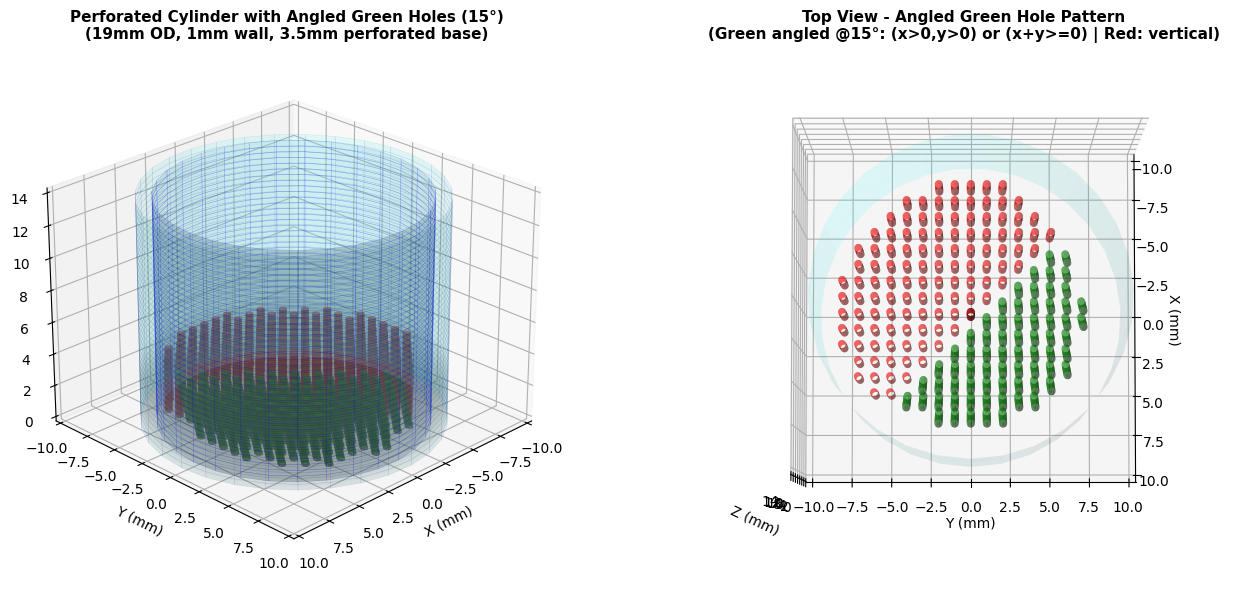

Cylinder Specifications (with Angled Green Holes):
  Outer Diameter: 19.0 mm
  Wall Thickness: 1.0 mm
  Inner Diameter: 17.0 mm
  Perforated Base Height: 3.5 mm
  Total Height: 14.0 mm
  Hole Spacing: 1.0 mm
  Hole Diameter: 0.5 mm
  Hole Pattern per Row: [5, 9, 11, 13, 15, 15, 17, 17, 17, 17, 17, 15, 13, 11, 9, 5]
  Total Number of Perforations: 183
  Central Hole Diameter: 0.5 mm (same as other holes)
  Central Hole at (x=0, y=0)
  Green holes: (x>0 AND y>0) OR (x+y>0) - ANGLED at 15°
  Red holes: all other positions - VERTICAL
  Green hole forward offset at top: 0.938 mm


In [36]:
# Create custom cylinder with perforated base (with angled green holes)
fig = plt.figure(figsize=(14, 6))

# Parameters (in mm)
outer_radius = 9.5      # 19mm diameter
inner_radius = 8.5      # 1mm wall thickness
perforated_height = 3.5
total_height = 14.0
hole_spacing = 1.0      # 1mm spacing between holes
hole_radius = 0.25      # 0.5mm hole diameter

# Hole pattern: number of holes in each row (y-axis)
# Pattern is symmetric around center
hole_rows = [5, 9, 11, 13, 15, 15, 17, 17, 17, 17, 17, 15, 13, 11, 9, 5]
num_rows = len(hole_rows)

# Angled hole parameters
angle_deg = 15
angle_rad = np.radians(angle_deg)
x_offset_per_height = np.tan(angle_rad) * perforated_height
print(f"Angled hole x-offset at top (z={perforated_height}mm): {x_offset_per_height:.3f} mm") # check point

# ===== Subplot 1: Full Assembly =====
ax1 = fig.add_subplot(121, projection='3d')

# Create outer cylinder (hollow) - more transparent
theta = np.linspace(0, 2*np.pi, 32)
z_outer = np.linspace(0, total_height, 40)
Theta, Z = np.meshgrid(theta, z_outer)

X_outer = outer_radius * np.cos(Theta)
Y_outer = outer_radius * np.sin(Theta)
ax1.plot_surface(X_outer, Y_outer, Z, color='cyan', alpha=0.1, edgecolor='navy', linewidth=0.3)

# Create inner cylinder (wall) - more transparent
X_inner = inner_radius * np.cos(Theta)
Y_inner = inner_radius * np.sin(Theta)
ax1.plot_surface(X_inner, Y_inner, Z, color='lightblue', alpha=0.25, edgecolor='blue', linewidth=0.3)

# Create bottom plate (perforated section - 0 to 3.5mm)
z_plate = np.linspace(0, perforated_height, 15)
for z_val in z_plate:
    r_circle = np.linspace(0, outer_radius, 20)
    theta_circle = np.linspace(0, 2*np.pi, 32)
    R, Theta_circ = np.meshgrid(r_circle, theta_circle)
    X_plate = R * np.cos(Theta_circ)
    Y_plate = R * np.sin(Theta_circ)
    Z_plate = np.ones_like(X_plate) * z_val
    ax1.plot_surface(X_plate, Y_plate, Z_plate, color='gray', alpha=0.05, shade=False)

# Create holes in the perforated section using the specified pattern
hole_count = 0
# Center the grid at (0, 0) - center hole is at row index 8 (the 3rd occurrence of 17 holes)
center_row_idx = 8

for row_idx, num_holes_in_row in enumerate(hole_rows):
    # Y position: center hole row is at y=0
    y_pos = (row_idx - center_row_idx) * hole_spacing
    
    # Calculate x positions for this row, centered at x=0
    x_center = (num_holes_in_row - 1) / 2.0 * hole_spacing
    x_positions = np.linspace(-x_center, x_center, num_holes_in_row)
    
    for x_pos in x_positions:
        distance_from_center = np.sqrt(x_pos**2 + y_pos**2)
        
        # Only create holes within outer radius
        if distance_from_center < outer_radius - 0.5:  # Leave margin from edge
            # Determine hole color: green if (x > 0 and y > 0) or (x + y > 0), otherwise red
            if (x_pos > 0 and y_pos > 0) or (x_pos + y_pos > 0):
                hole_color = 'green'
                is_angled = True
            else:
                hole_color = 'red'
                is_angled = False
            
            # Check if hole hits the wall (for angled holes, check both bottom and top)
            # We check if the hole edge is within 2mm of the outer wall
            if is_angled:
                # Bottom of hole (z=0): original position
                dist_bottom = np.sqrt(x_pos**2 + y_pos**2) + hole_radius
                # Top of hole (z=3.5mm): offset position
                dist_top = np.sqrt((x_pos + x_offset_per_height)**2 + y_pos**2) + hole_radius
                
                # Skip this hole if the edge is within 2mm of the wall at any point
                if dist_bottom >= outer_radius - 2 or dist_top >= outer_radius - 2:
                    continue
            
            # Draw hole as a vertical cylinder (or angled for green holes)
            z_hole = np.linspace(0, perforated_height, 15)
            theta_hole = np.linspace(0, 2*np.pi, 16)
            Theta_h, Z_h = np.meshgrid(theta_hole, z_hole)
            
            if is_angled:
                # For green holes, apply angular offset based on height
                z_ratio = Z_h / perforated_height
                x_offset = x_offset_per_height * z_ratio
                X_h = (x_pos + x_offset) + hole_radius * np.cos(Theta_h)
            else:
                X_h = x_pos + hole_radius * np.cos(Theta_h)
            
            Y_h = y_pos + hole_radius * np.sin(Theta_h)
            ax1.plot_surface(X_h, Y_h, Z_h, color=hole_color, alpha=0.7)
            hole_count += 1

# Central hole (same size as other holes, centered at 0,0, only through perforated section)
z_central = np.linspace(0, perforated_height, 15)
theta_central = np.linspace(0, 2*np.pi, 20)
Theta_c, Z_c = np.meshgrid(theta_central, z_central)
X_central = hole_radius * np.cos(Theta_c)
Y_central = hole_radius * np.sin(Theta_c)
ax1.plot_surface(X_central, Y_central, Z_c, color='darkred', alpha=0.8)

ax1.set_xlabel('X (mm)', fontsize=10)
ax1.set_ylabel('Y (mm)', fontsize=10)
ax1.set_zlabel('Z (mm)', fontsize=10)
ax1.set_title('Perforated Cylinder with Angled Green Holes (15°)\n(19mm OD, 1mm wall, 3.5mm perforated base)', 
              fontsize=11, fontweight='bold')
ax1.set_xlim([-10, 10])
ax1.set_ylim([-10, 10])
ax1.view_init(elev=25, azim=45)

# ===== Subplot 2: Bottom View (looking down at holes) =====
ax2 = fig.add_subplot(122, projection='3d')

# Draw outer cylinder outline - more transparent
ax2.plot_surface(X_outer, Y_outer, Z, color='cyan', alpha=0.1)

# Draw holes from top view with angled green holes
for row_idx, num_holes_in_row in enumerate(hole_rows):
    y_pos = (row_idx - center_row_idx) * hole_spacing
    
    x_center = (num_holes_in_row - 1) / 2.0 * hole_spacing
    x_positions = np.linspace(-x_center, x_center, num_holes_in_row)
    
    for x_pos in x_positions:
        distance_from_center = np.sqrt(x_pos**2 + y_pos**2)
        
        if distance_from_center < outer_radius - 0.5:
            # Determine hole color: green if (x > 0 and y > 0) or (x + y > 0), otherwise red
            if (x_pos > 0 and y_pos > 0) or (x_pos + y_pos > 0):
                hole_color = 'green'
                is_angled = True
            else:
                hole_color = 'red'
                is_angled = False
            
            # We check if the hole edge is within 2mm of the outer wall
            if is_angled:
                # Bottom of hole (z=0): original position
                dist_bottom = np.sqrt(x_pos**2 + y_pos**2) + hole_radius
                # Top of hole (z=3.5mm): offset position
                dist_top = np.sqrt((x_pos + x_offset_per_height)**2 + y_pos**2) + hole_radius
                
                # Skip this hole if the edge is within 2mm of the wall at any point
                if dist_bottom >= outer_radius - 2 or dist_top >= outer_radius - 2:
                    continue
            
            z_hole = np.linspace(0, perforated_height, 15)
            theta_hole = np.linspace(0, 2*np.pi, 16)
            Theta_h, Z_h = np.meshgrid(theta_hole, z_hole)
            
            if is_angled:
                # For green holes, apply angular offset based on height
                z_ratio = Z_h / perforated_height
                x_offset = x_offset_per_height * z_ratio
                X_h = (x_pos + x_offset) + hole_radius * np.cos(Theta_h)
            else:
                X_h = x_pos + hole_radius * np.cos(Theta_h)
            
            Y_h = y_pos + hole_radius * np.sin(Theta_h)
            ax2.plot_surface(X_h, Y_h, Z_h, color=hole_color, alpha=0.8)

# Central hole (same size as other holes)
ax2.plot_surface(X_central, Y_central, Z_c, color='darkred', alpha=0.9)

ax2.set_xlabel('X (mm)', fontsize=10)
ax2.set_ylabel('Y (mm)', fontsize=10)
ax2.set_zlabel('Z (mm)', fontsize=10)
ax2.set_title('Top View - Angled Green Hole Pattern\n(Green angled @15°: (x>0,y>0) or (x+y>=0) | Red: vertical)', 
              fontsize=11, fontweight='bold')
ax2.set_xlim([-10, 10])
ax2.set_ylim([-10, 10])
ax2.view_init(elev=85, azim=0)  # Nearly top-down view

plt.tight_layout()
plt.show()

print(f"Cylinder Specifications (with Angled Green Holes):")
print(f"  Outer Diameter: 19.0 mm")
print(f"  Wall Thickness: 1.0 mm")
print(f"  Inner Diameter: 17.0 mm")
print(f"  Perforated Base Height: {perforated_height} mm")
print(f"  Total Height: {total_height} mm")
print(f"  Hole Spacing: {hole_spacing} mm")
print(f"  Hole Diameter: {hole_radius * 2} mm")
print(f"  Hole Pattern per Row: {hole_rows}")
print(f"  Total Number of Perforations: {hole_count}")
print(f"  Central Hole Diameter: {hole_radius * 2} mm (same as other holes)")
print(f"  Central Hole at (x=0, y=0)")
print(f"  Green holes: (x>0 AND y>0) OR (x+y>0) - ANGLED at {angle_deg}°")
print(f"  Red holes: all other positions - VERTICAL")

print(f"  Green hole forward offset at top: {x_offset_per_height:.3f} mm")


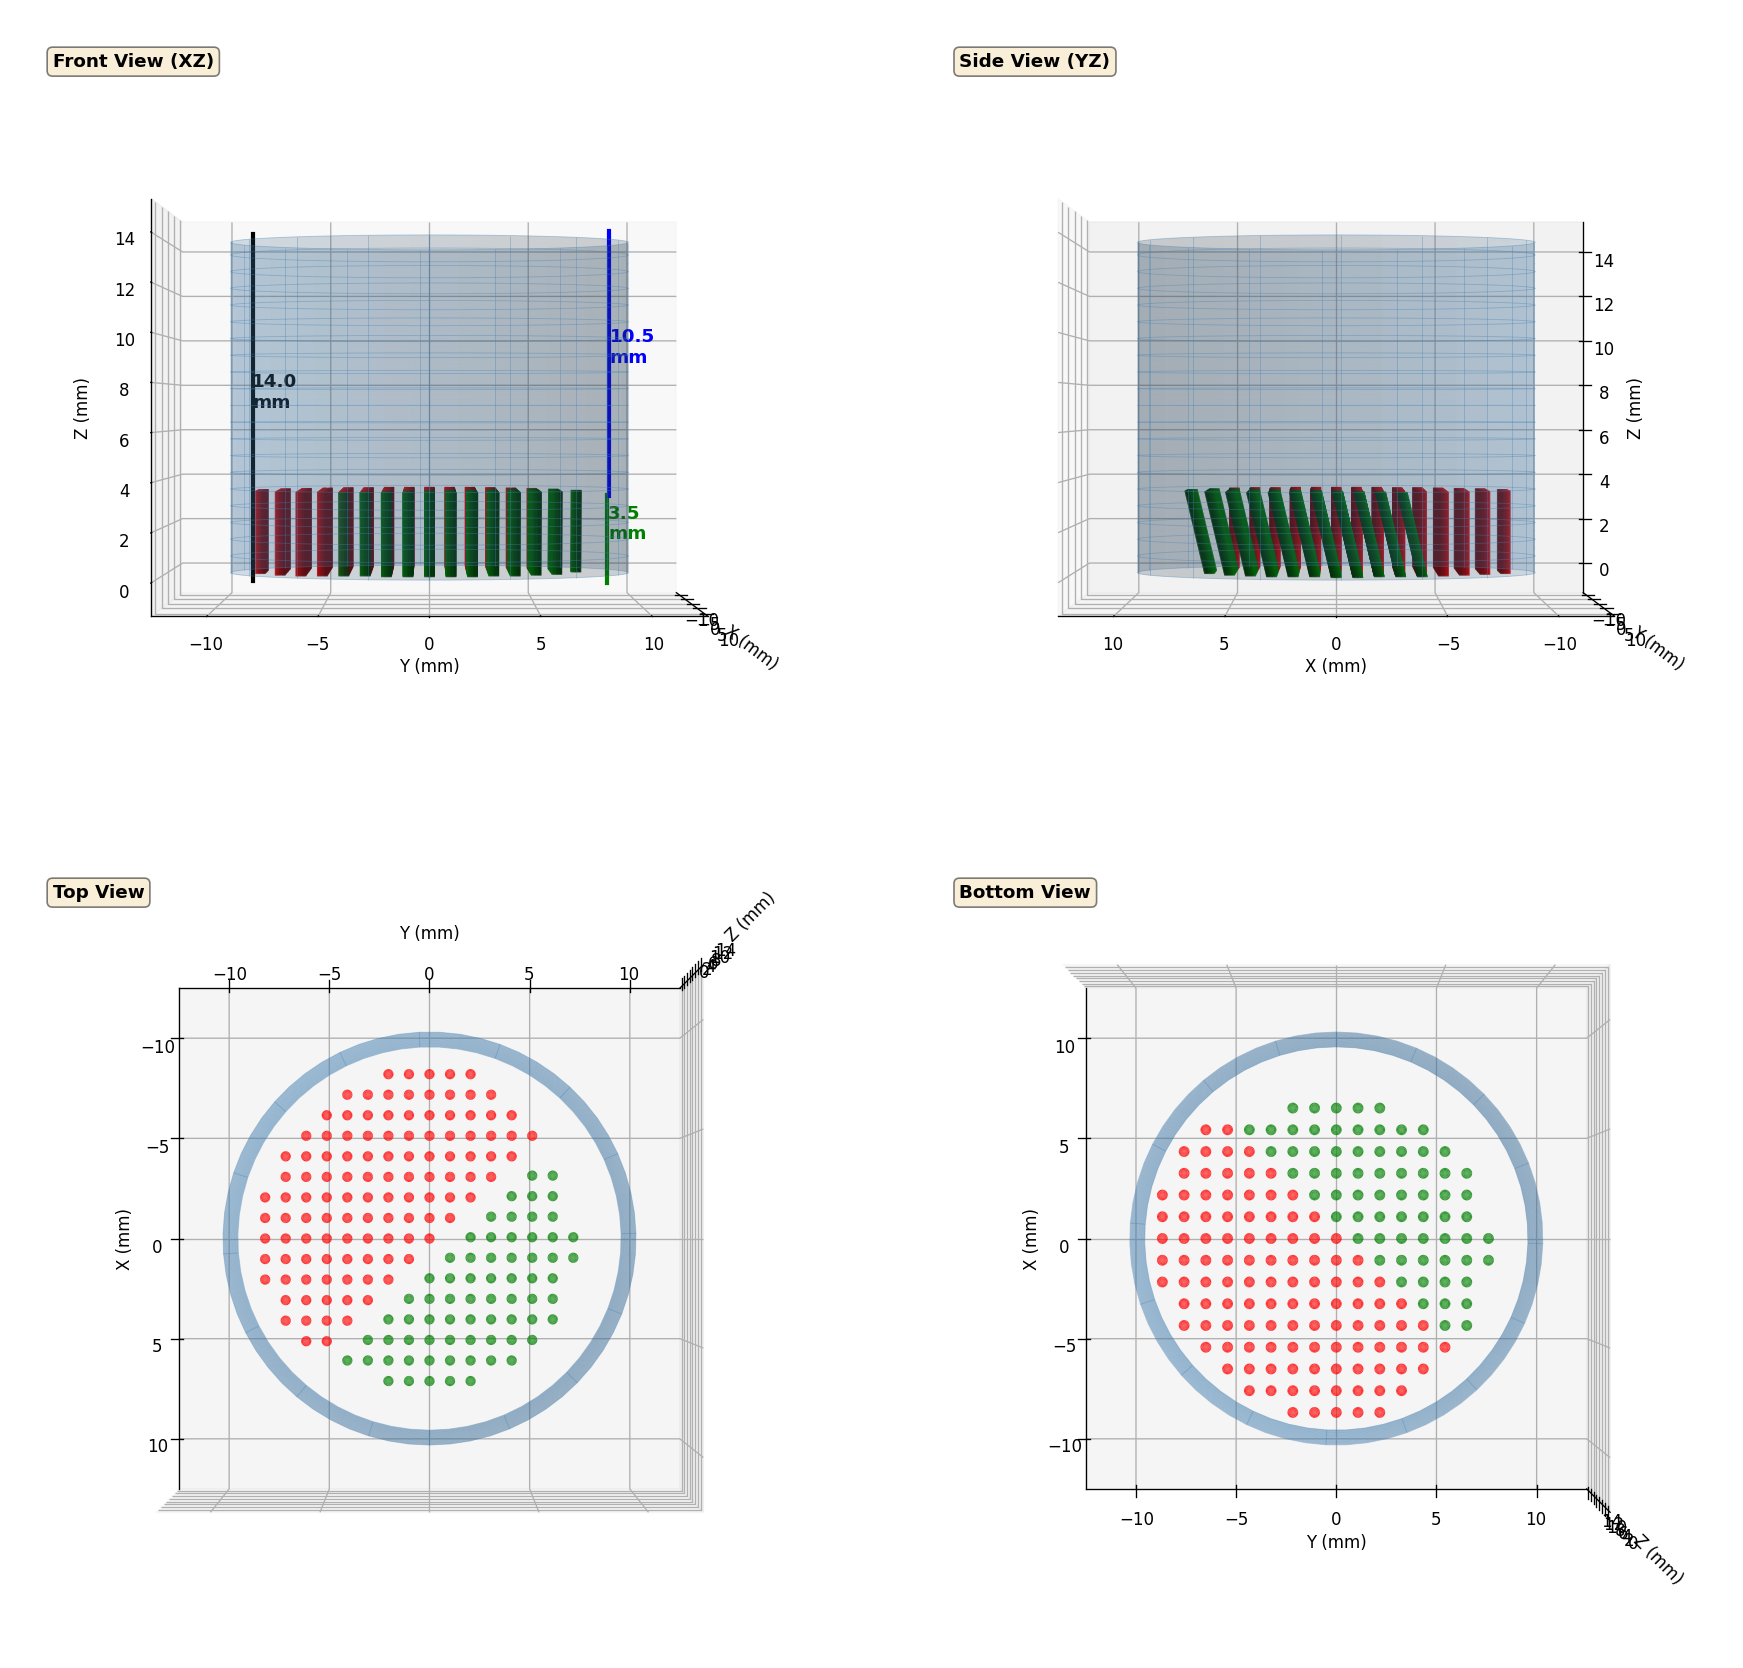


Four-View Cylinder Analysis (High Resolution):
Total Cylinder Height: 14.0 mm
Perforated Base Height: 3.5 mm
Internal (Solid) Height: 10.5 mm
Cylinder OD: 19.0 mm | Wall Thickness: 1.0 mm | ID: 17.0 mm

Hole Count Details:
  Total Holes Rendered: 732
  Holes Skipped (collision): 92
  Green Holes: ANGLED at 15°
  Red Holes: VERTICAL
  Green Hole Forward Offset: 0.938 mm


In [52]:
# Four-view visualization with higher resolution
fig = plt.figure(figsize=(16, 14), dpi=120)

# Parameters (in mm)
outer_radius = 9.5      # 19mm diameter
inner_radius = 8.5      # 1mm wall thickness
perforated_height = 3.5
total_height = 14.0
hole_spacing = 1.0
hole_radius = 0.25

hole_rows = [5, 9, 11, 13, 15, 15, 17, 17, 17, 17, 17, 15, 13, 11, 9, 5]
num_rows = len(hole_rows)

angle_deg = 15
angle_rad = np.radians(angle_deg)
x_offset_per_height = np.tan(angle_rad) * perforated_height

center_row_idx = 8

# Create meshgrid for cylinder surfaces with HIGH RESOLUTION
theta = np.linspace(0, 2*np.pi, 64)  # Increased from 32
z_outer = np.linspace(0, total_height, 80)  # Increased from 40
Theta, Z = np.meshgrid(theta, z_outer)

X_outer = outer_radius * np.cos(Theta)
Y_outer = outer_radius * np.sin(Theta)

# Central hole
z_central = np.linspace(0, perforated_height, 20)  # Increased from 15
theta_central = np.linspace(0, 2*np.pi, 32)  # Increased from 20
Theta_c, Z_c = np.meshgrid(theta_central, z_central)
X_central = hole_radius * np.cos(Theta_c)
Y_central = hole_radius * np.sin(Theta_c)

# Define viewing angles and what to display
# Format: (elev, azim, view_type)
# view_type: 'full', 'top_surface', 'bottom_surface'
views = [
    (0, 0, 'full'),               # Front View (XZ plane) - full hole
    (0, 90, 'full'),              # Side View (YZ plane) - full hole
    (90, 0, 'top_surface'),       # Top View (XY plane) - only top surface
    (-90, 0, 'bottom_surface'),   # Bottom View - only bottom surface
]

view_names = ['Front View (XZ)', 'Side View (YZ)', 'Top View', 'Bottom View']

hole_count = 0
hole_count_skipped = 0

for idx, (elev, azim, view_type) in enumerate(views):
    ax = fig.add_subplot(2, 2, idx+1, projection='3d')
    
    # Draw ONLY the outer cylinder wall - smooth appearance with light wireframe overlay
    ax.plot_surface(X_outer, Y_outer, Z, color='steelblue', alpha=0.2, edgecolor='none', shade=True)
    # Add wireframe overlay for edge clarity
    ax.plot_wireframe(X_outer, Y_outer, Z, color='steelblue', alpha=0.4, linewidth=0.5, rstride=4, cstride=4)
    
    # Draw all holes with higher resolution
    for row_idx, num_holes_in_row in enumerate(hole_rows):
        y_pos = (row_idx - center_row_idx) * hole_spacing
        x_center = (num_holes_in_row - 1) / 2.0 * hole_spacing
        x_positions = np.linspace(-x_center, x_center, num_holes_in_row)
        
        for x_pos in x_positions:
            distance_from_center = np.sqrt(x_pos**2 + y_pos**2)
            
            if distance_from_center < outer_radius - 0.5:
                if (x_pos > 0 and y_pos > 0) or (x_pos + y_pos > 0):
                    hole_color = 'green'
                    is_angled = True
                else:
                    hole_color = 'red'
                    is_angled = False
                
                # Check collision for angled holes
                if is_angled:
                    dist_bottom = np.sqrt(x_pos**2 + y_pos**2) + hole_radius
                    dist_top = np.sqrt((x_pos + x_offset_per_height)**2 + y_pos**2) + hole_radius
                    
                    if dist_bottom >= outer_radius - 2 or dist_top >= outer_radius - 2:
                        hole_count_skipped += 1
                        continue
                
                # High resolution holes - render based on view type
                if view_type == 'bottom_surface':
                    # Only draw bottom surface (thin disc at z=0)
                    theta_hole = np.linspace(0, 2*np.pi, 24)
                    for r_idx in range(len(theta_hole)-1):
                        theta1, theta2 = theta_hole[r_idx], theta_hole[r_idx+1]
                        x_surface = np.array([
                            [x_pos, x_pos],
                            [x_pos + hole_radius*np.cos(theta1), x_pos + hole_radius*np.cos(theta2)]
                        ])
                        y_surface = np.array([
                            [y_pos, y_pos],
                            [y_pos + hole_radius*np.sin(theta1), y_pos + hole_radius*np.sin(theta2)]
                        ])
                        z_surface = np.zeros((2, 2))
                        ax.plot_surface(x_surface, y_surface, z_surface, color=hole_color, alpha=0.8, edgecolor='none')
                    
                elif view_type == 'top_surface':
                    # Only draw top surface (thin disc at z=perforated_height)
                    if is_angled:
                        # For angled holes, top is offset
                        x_pos_top = x_pos + x_offset_per_height
                    else:
                        x_pos_top = x_pos
                    
                    theta_hole = np.linspace(0, 2*np.pi, 24)
                    for r_idx in range(len(theta_hole)-1):
                        theta1, theta2 = theta_hole[r_idx], theta_hole[r_idx+1]
                        x_surface = np.array([
                            [x_pos_top, x_pos_top],
                            [x_pos_top + hole_radius*np.cos(theta1), x_pos_top + hole_radius*np.cos(theta2)]
                        ])
                        y_surface = np.array([
                            [y_pos, y_pos],
                            [y_pos + hole_radius*np.sin(theta1), y_pos + hole_radius*np.sin(theta2)]
                        ])
                        z_surface = np.ones((2, 2)) * perforated_height
                        ax.plot_surface(x_surface, y_surface, z_surface, color=hole_color, alpha=0.8, edgecolor='none')
                    
                else:  # view_type == 'full'
                    # Draw full hole cylinder
                    z_hole = np.linspace(0, perforated_height, 20)
                    theta_hole = np.linspace(0, 2*np.pi, 24)
                    Theta_h, Z_h = np.meshgrid(theta_hole, z_hole)
                    
                    if is_angled:
                        z_ratio = Z_h / perforated_height
                        x_offset = x_offset_per_height * z_ratio
                        X_h = (x_pos + x_offset) + hole_radius * np.cos(Theta_h)
                    else:
                        X_h = x_pos + hole_radius * np.cos(Theta_h)
                    
                    Y_h = y_pos + hole_radius * np.sin(Theta_h)
                    ax.plot_surface(X_h, Y_h, Z_h, color=hole_color, alpha=0.7, edgecolor='none')
                
                hole_count += 1
    
    
    # Add height annotations ONLY for XZ plane view (Front View, index 0)
    if idx == 0:
        # Line showing total height
        ax.plot([11, 11], [-8, -8], [0, total_height], 'k-', linewidth=2.5)
        ax.text(11.8, -8, total_height/2, f'{total_height}\nmm', fontsize=11, fontweight='bold', color='black')
        
        # Line showing perforated height
        ax.plot([12.5, 12.5], [8, 8], [0, perforated_height], 'g-', linewidth=2.5)
        ax.text(13.2, 8, perforated_height/2, f'{perforated_height}\nmm', fontsize=11, fontweight='bold', color='green')
        
        # Line showing internal height
        internal_height = total_height - perforated_height
        ax.plot([14, 14], [8, 8], [perforated_height, total_height], 'b-', linewidth=2.5)
        ax.text(14.7, 8, perforated_height + internal_height/2, f'{internal_height}\nmm', fontsize=11, fontweight='bold', color='blue')
    
    ax.set_xlabel('X (mm)', fontsize=10, labelpad=8)
    ax.set_ylabel('Y (mm)', fontsize=10, labelpad=8)
    ax.set_zlabel('Z (mm)', fontsize=10, labelpad=8)
    ax.set_xlim([-12, 12])
    ax.set_ylim([-12, 12])
    ax.set_zlim([-1, 15])
    ax.view_init(elev=elev, azim=azim)
    
    # Add view name as text on the plot (instead of title)
    ax.text2D(0.05, 0.95, view_names[idx], transform=ax.transAxes, fontsize=11, fontweight='bold',
              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"Four-View Cylinder Analysis (High Resolution):")
print(f"{'='*60}")
print(f"Total Cylinder Height: {total_height} mm")
print(f"Perforated Base Height: {perforated_height} mm")
print(f"Internal (Solid) Height: {total_height - perforated_height} mm")
print(f"Cylinder OD: 19.0 mm | Wall Thickness: 1.0 mm | ID: 17.0 mm")
print(f"\nHole Count Details:")
print(f"  Total Holes Rendered: {hole_count}")
print(f"  Holes Skipped (collision): {hole_count_skipped}")
print(f"  Green Holes: ANGLED at {angle_deg}°")
print(f"  Red Holes: VERTICAL")
print(f"  Green Hole Forward Offset: {x_offset_per_height:.3f} mm")
print(f"{'='*60}")